# Time-Resolved Decoding

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next(path for path in (cwd, *cwd.parents) if (path / 'scripts' / 'config.py').exists())
SCRIPTS_DIR = REPO_ROOT / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import config
EPOCHS_ROOT = REPO_ROOT / 'output_mne' / 'epochs'

from decoding.decoding_utils.plotting import plot_time_resolved_decoding_summary
from decoding.decoding_utils.time_resolved_decoding_utils import run_group_decoding
from decoding.decoding_utils.epoch_io import get_epochs_path

In [ ]:
PIPELINE = 'proposed'
CONTEXTS = ['mid_high', 'high_high']
WINDOW_START = 0.24
WINDOW_END = 0.34
#SUBJECTS = sorted(config.SUBJECT_INFO) 
SUBJECTS = sorted(
    sub for sub, info in config.SUBJECT_INFO.items()
    if info["learner"]
)

subjects_to_run = [
    sid for sid in SUBJECTS
    if get_epochs_path(sid, PIPELINE, 'feedback', root_dir=EPOCHS_ROOT).exists()
]
if not subjects_to_run:
    raise FileNotFoundError('No saved feedback epochs found. Run make_feedback_epochs.ipynb first.')

summary_df, _, timecourse_store = run_group_decoding(
    subjects_to_run,
    PIPELINE,
    CONTEXTS,
    window_start=WINDOW_START,
    window_end=WINDOW_END,
    root_dir=EPOCHS_ROOT,
)
summary_df

,subject_id,context,n_trials,n_win,n_loss,cv_splits,window_start_sec,window_end_sec,window_auc_mean,peak_auc,peak_time_sec
0,27,mid_high,67,42,25,5,0.24,0.34,0.580128,0.753333,-0.168
1,27,high_high,133,77,56,5,0.24,0.34,0.519919,0.685884,0.156
2,28,mid_high,53,45,8,5,0.24,0.34,0.664103,0.911111,-0.028
3,28,high_high,32,27,5,5,0.24,0.34,0.678974,0.960000,0.032
4,31,mid_high,64,41,23,5,0.24,0.34,0.616907,0.906250,0.156
5,31,high_high,131,95,36,5,0.24,0.34,0.606051,0.864098,0.100
6,34,mid_high,65,44,21,5,0.24,0.34,0.495748,0.782222,0.168
7,34,high_high,132,88,44,5,0.24,0.34,0.556908,0.656618,0.328
8,35,mid_high,59,48,11,5,0.24,0.34,0.504843,0.770741,-0.184
9,35,high_high,129,82,47,5,0.24,0.34,0.560493,0.663783,0.156


['mid_high', 'high_high']

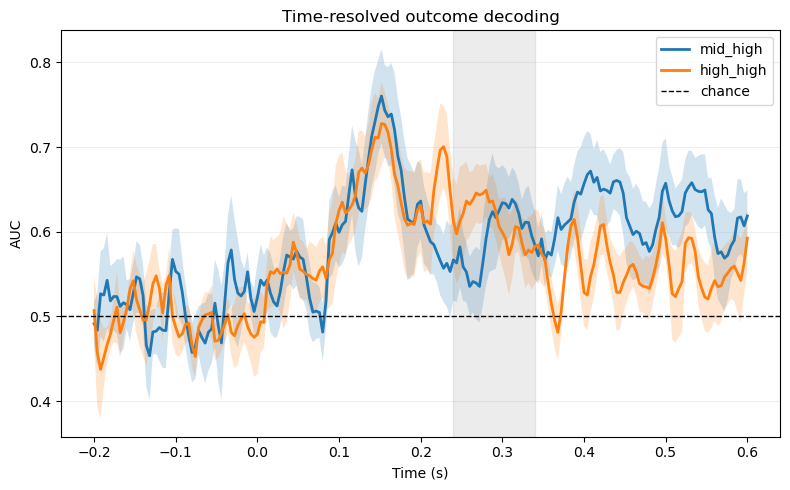

In [7]:
fig, ax, plotted_contexts = plot_time_resolved_decoding_summary(
    timecourse_store,
    subjects_to_run,
    CONTEXTS,
    WINDOW_START,
    WINDOW_END,
)
plotted_contexts
